In [6]:
# TUGAS 1: Implementasi Sobel Manual
def sobel_from_scratch(image_array):
    """
    Deteksi tepi menggunakan Sobel dari scratch.
    Returns: Gx, Gy, magnitude, angle, threshold_result
    """
    # 1. Definisikan kernel Gx (horizontal) dan Gy (vertikal)
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float64)
                   
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]], dtype=np.float64)
    
    # 2. Lakukan Konvolusi menggunakan fungsi manual yang sudah kita buat
    Gx = convolve2d_manual(image_array, Kx)
    Gy = convolve2d_manual(image_array, Ky)
    
    # 3. Hitung magnitude dan arah gradien
    magnitude = np.sqrt(Gx**2 + Gy**2)
    
    # arctan2 menghasilkan radian, kita ubah ke derajat
    angle = np.arctan2(Gy, Gx) * 180 / np.pi 
    
    # 4. Thresholding (gunakan threshold = 50 sesuai instruksi PDF)
    threshold = 50
    # Jika nilai magnitude lebih besar dari threshold, jadikan 255 (putih), sisanya 0 (hitam)
    result = np.where(magnitude >= threshold, 255, 0).astype(np.uint8)
    
    return Gx, Gy, magnitude, angle, result

# Mari kita jalankan fungsinya pada gambar yang sudah diload sebelumnya (variabel 'img')
Gx, Gy, mag, ang, result_thresh = sobel_from_scratch(img)
print("Deteksi tepi Sobel manual selesai dieksekusi!")

Deteksi tepi Sobel manual selesai dieksekusi!


RMSE Magnitude (Manual vs OpenCV): 0.0000


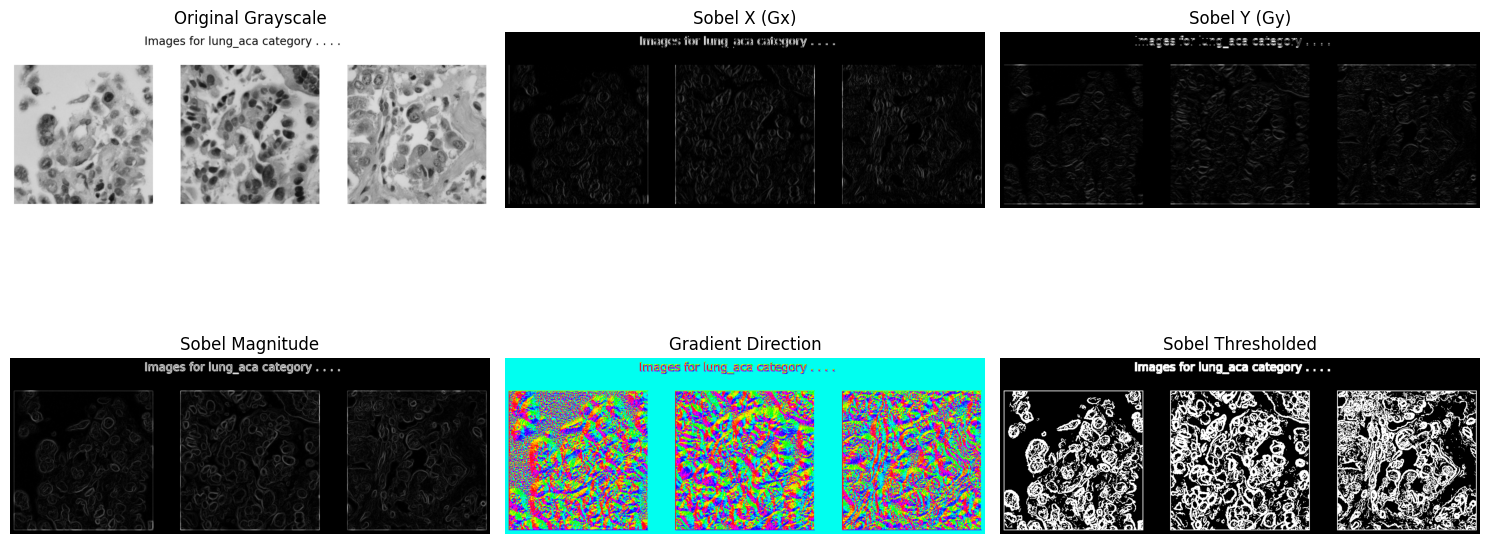

In [7]:
# TUGAS 1: Perbandingan dengan OpenCV & Visualisasi Akhir

# 1. Jalankan Sobel bawaan OpenCV sebagai pembanding
gx_cv = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy_cv = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
mag_cv = np.sqrt(gx_cv**2 + gy_cv**2)

# 2. Hitung RMSE (Root Mean Square Error) antara OpenCV vs Manual
# Rumus: akar kuadrat dari rata-rata selisih kuadrat
rmse = np.sqrt(np.mean((mag_cv - mag)**2))
print(f'RMSE Magnitude (Manual vs OpenCV): {rmse:.4f}')

# 3. VISUALISASI HASIL (Membuat 6 gambar berdampingan)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Baris atas
axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title('Original Grayscale')
axes[0,0].axis('off')

axes[0,1].imshow(np.abs(Gx), cmap='gray')
axes[0,1].set_title('Sobel X (Gx)')
axes[0,1].axis('off')

axes[0,2].imshow(np.abs(Gy), cmap='gray')
axes[0,2].set_title('Sobel Y (Gy)')
axes[0,2].axis('off')

# Baris bawah
axes[1,0].imshow(mag, cmap='gray')
axes[1,0].set_title('Sobel Magnitude')
axes[1,0].axis('off')

# Peta arah gradien biasanya menggunakan colormap 'hsv' (warna-warni)
axes[1,1].imshow(ang, cmap='hsv')
axes[1,1].set_title('Gradient Direction')
axes[1,1].axis('off')

axes[1,2].imshow(result_thresh, cmap='gray')
axes[1,2].set_title('Sobel Thresholded')
axes[1,2].axis('off')

# Rapikan tata letak dan tampilkan
plt.tight_layout()
plt.show()

In [1]:
import time
from itertools import product

# TUGAS 2: Analisis Parameter Canny & Perbandingan Metode
def canny_parameter_sweep(gray_img, sigmas, low_thresholds, high_thresholds):
    """
    Lakukan parameter sweep untuk Canny.
    Returns: dict dengan key (sigma, low, high) -> (edge_image, edge_count)
    """
    results = {}
    
    # Looping otomatis untuk mencoba semua kombinasi parameter
    for sigma, low, high in product(sigmas, low_thresholds, high_thresholds):
        if low >= high:
            continue # Skip kombinasi tidak valid (low tidak boleh lebih besar dari high)
            
        # 1. Tahap Gaussian Blur (ksize dihitung otomatis dari sigma agar presisi)
        ksize = int(6 * sigma + 1)
        if ksize % 2 == 0: 
            ksize += 1 # Ksize harus bilangan ganjil
            
        blurred = cv2.GaussianBlur(gray_img, (ksize, ksize), sigmaX=sigma)
        
        # 2. Tahap Canny Edge Detection
        edges = cv2.Canny(blurred, low, high)
        
        # 3. Hitung jumlah piksel tepi (yang bernilai 255 / warna putih)
        edge_count = np.sum(edges == 255)
        
        # Simpan hasil gambar dan jumlah tepinya
        results[(sigma, low, high)] = (edges, edge_count)
        
    return results

print("Fungsi Parameter Sweep Canny siap!")


Fungsi Parameter Sweep Canny siap!


In [2]:
import time
from itertools import product

# TUGAS 2: Analisis Parameter Canny & Perbandingan Metode
def canny_parameter_sweep(gray_img, sigmas, low_thresholds, high_thresholds):
    """
    Lakukan parameter sweep untuk Canny.
    Returns: dict dengan key (sigma, low, high) -> (edge_image, edge_count)
    """
    results = {}
    
    # Looping otomatis untuk mencoba semua kombinasi parameter
    for sigma, low, high in product(sigmas, low_thresholds, high_thresholds):
        if low >= high:
            continue # Skip kombinasi tidak valid (low tidak boleh lebih besar dari high)
            
        # 1. Tahap Gaussian Blur (ksize dihitung otomatis dari sigma agar presisi)
        ksize = int(6 * sigma + 1)
        if ksize % 2 == 0: 
            ksize += 1 # Ksize harus bilangan ganjil
            
        blurred = cv2.GaussianBlur(gray_img, (ksize, ksize), sigmaX=sigma)
        
        # 2. Tahap Canny Edge Detection
        edges = cv2.Canny(blurred, low, high)
        
        # 3. Hitung jumlah piksel tepi (yang bernilai 255 / warna putih)
        edge_count = np.sum(edges == 255)
        
        # Simpan hasil gambar dan jumlah tepinya
        results[(sigma, low, high)] = (edges, edge_count)
        
    return results

print("Fungsi Parameter Sweep Canny siap!")

Fungsi Parameter Sweep Canny siap!


In [3]:
# TUGAS 2: Visualisasi Heat Map & Perbandingan Kuantitatif

def plot_parameter_heatmap(sweep_results, fixed_sigma):
    """
    Visualisasikan jumlah tepi sebagai heatmap untuk sigma tertentu.
    Sumbu X = high_threshold, Sumbu Y = low_threshold
    """
    # 1. Ambil semua hasil yang sigmanya sesuai dengan fixed_sigma
    valid_results = {k: v for k, v in sweep_results.items() if k[0] == fixed_sigma}
    
    # 2. Ambil daftar unik dari low_threshold dan high_threshold
    low_threshs = sorted(list(set([k[1] for k in valid_results.keys()])))
    high_threshs = sorted(list(set([k[2] for k in valid_results.keys()])))
    
    # 3. Buat matriks kosong untuk menampung jumlah piksel tepi
    matrix = np.zeros((len(low_threshs), len(high_threshs)))
    
    # 4. Isi matriks dengan data edge_count
    for i, low in enumerate(low_threshs):
        for j, high in enumerate(high_threshs):
            if (fixed_sigma, low, high) in valid_results:
                matrix[i, j] = valid_results[(fixed_sigma, low, high)][1] # Ambil edge_count
            else:
                matrix[i, j] = np.nan # Kosongkan jika kombinasi tidak valid (low >= high)

    # 5. Visualisasi Heat Map dengan Matplotlib
    plt.figure(figsize=(8, 6))
    im = plt.imshow(matrix, cmap='plasma', origin='lower')
    
    plt.xticks(np.arange(len(high_threshs)), high_threshs)
    plt.yticks(np.arange(len(low_threshs)), low_threshs)
    plt.xlabel('High Threshold')
    plt.ylabel('Low Threshold')
    plt.title(f'Heat Map Jumlah Piksel Tepi (Sigma = {fixed_sigma})')
    plt.colorbar(im, label='Jumlah Piksel Tepi')
    plt.show()

def compare_methods(image_path):
    """
    Bandingkan Sobel vs Canny secara kuantitatif.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
        
    total_pixels = img.shape[0] * img.shape[1]
    
    # --- Proses SOBEL ---
    t0 = time.perf_counter()
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_edges = np.where(sobel_mag >= 50, 255, 0).astype(np.uint8)
    sobel_time = (time.perf_counter() - t0) * 1000 # Ubah ke ms
    
    sobel_edge_pixels = np.sum(sobel_edges == 255)
    
    # --- Proses CANNY ---
    t0 = time.perf_counter()
    canny_edges = cv2.Canny(img, 50, 150)
    canny_time = (time.perf_counter() - t0) * 1000 # Ubah ke ms
    
    canny_edge_pixels = np.sum(canny_edges == 255)
    
    # Kumpulkan metrik ke dalam dictionary
    metrics = {
        'sobel_edge_pixels': sobel_edge_pixels,
        'canny_edge_pixels': canny_edge_pixels,
        'sobel_time_ms': round(sobel_time, 2),
        'canny_time_ms': round(canny_time, 2),
        'sobel_edge_density': round(sobel_edge_pixels / total_pixels, 4),
        'canny_edge_density': round(canny_edge_pixels / total_pixels, 4)
    }
    return metrics

print("Fungsi Heat Map dan Komparasi Kuantitatif siap!")

Fungsi Heat Map dan Komparasi Kuantitatif siap!



🔄 Memproses: image1.jpg
Menghitung kombinasi parameter Canny...


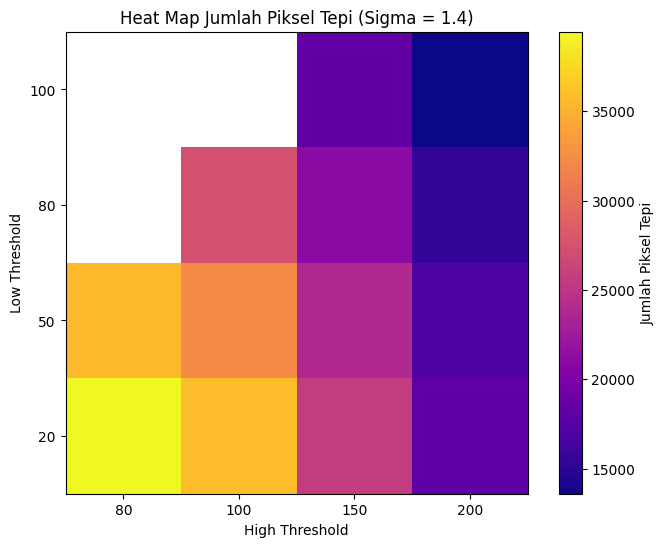


📊 Hasil Perbandingan Kuantitatif untuk image1.jpg:
  - sobel_edge_pixels   : 153559 piksel
  - canny_edge_pixels   : 50155 piksel
  - sobel_time_ms       : 19.03 ms
  - canny_time_ms       : 3.92 ms
  - sobel_edge_density  : 0.3 (rasio)
  - canny_edge_density  : 0.098 (rasio)

🔄 Memproses: image2.jpg
Menghitung kombinasi parameter Canny...


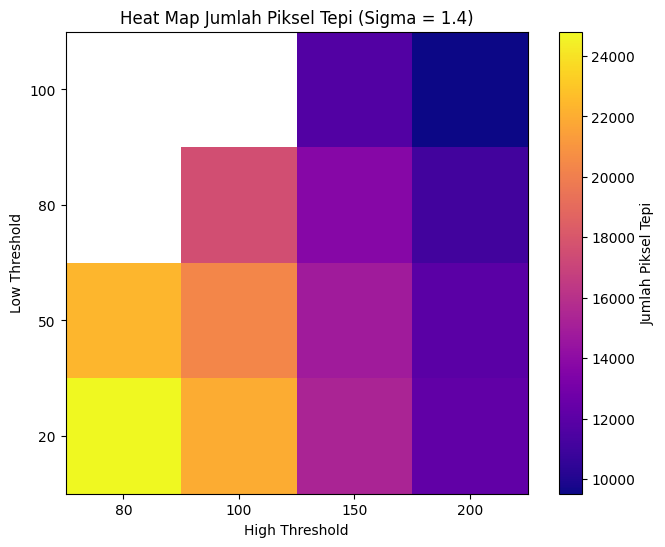


📊 Hasil Perbandingan Kuantitatif untuk image2.jpg:
  - sobel_edge_pixels   : 92027 piksel
  - canny_edge_pixels   : 26305 piksel
  - sobel_time_ms       : 14.34 ms
  - canny_time_ms       : 2.15 ms
  - sobel_edge_density  : 0.1798 (rasio)
  - canny_edge_density  : 0.0514 (rasio)

🔄 Memproses: image3.jpg
Menghitung kombinasi parameter Canny...


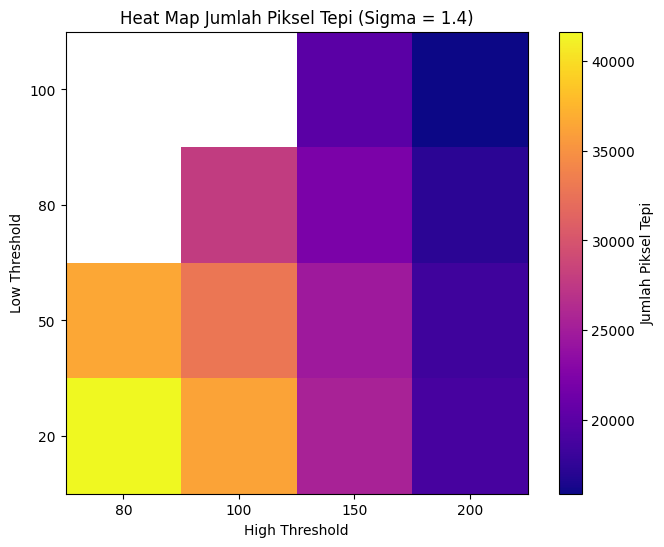


📊 Hasil Perbandingan Kuantitatif untuk image3.jpg:
  - sobel_edge_pixels   : 161016 piksel
  - canny_edge_pixels   : 54488 piksel
  - sobel_time_ms       : 20.71 ms
  - canny_time_ms       : 2.68 ms
  - sobel_edge_density  : 0.3146 (rasio)
  - canny_edge_density  : 0.1065 (rasio)


In [5]:
# TUGAS 2: Main Program (Eksekusi Parameter Sweep & Komparasi)

import cv2
import numpy as np
import matplotlib.pyplot as plt
# 1. Daftar gambar dan kombinasi parameter yang akan diuji
IMAGE_PATHS = ['image1.jpg', 'image2.jpg', 'image3.jpg']
sigmas = [0.5, 1.0, 1.4, 2.0]
low_thresholds = [20, 50, 80, 100]
high_thresholds = [80, 100, 150, 200]

# 2. Loop melalui setiap gambar
for path in IMAGE_PATHS:
    # Load gambar
    gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    # Cek apakah gambar berhasil diload (untuk mencegah error)
    if gray is None:
        print(f"⚠️ Gambar {path} tidak ditemukan. Pastikan namanya sudah benar!")
        continue
        
    print(f"\n=========================================")
    print(f"🔄 Memproses: {path}")
    print(f"=========================================")
    
    # 3. Jalankan Parameter Sweep
    print("Menghitung kombinasi parameter Canny...")
    results = canny_parameter_sweep(gray, sigmas, low_thresholds, high_thresholds)
    
    # 4. Tampilkan Heat Map untuk sigma 1.4
    plot_parameter_heatmap(results, fixed_sigma=1.4)
    
    # 5. Hitung dan Tampilkan Metrik Perbandingan Sobel vs Canny
    metrics = compare_methods(path)
    if metrics:
        print(f"\n📊 Hasil Perbandingan Kuantitatif untuk {path}:")
        for k, v in metrics.items():
            # Format output agar lebih rapi
            if 'time_ms' in k:
                print(f"  - {k:<20}: {v} ms")
            elif 'density' in k:
                print(f"  - {k:<20}: {v} (rasio)")
            else:
                print(f"  - {k:<20}: {v} piksel")

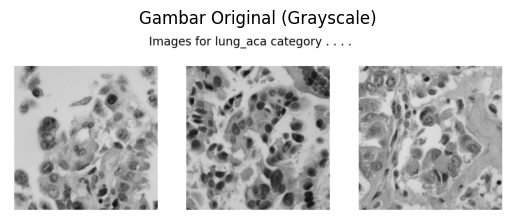

In [4]:
# TUGAS 1: Sobel Edge Detection dari Scratch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Tentukan path gambar yang sudah kamu siapkan
IMAGE_PATH = 'test_image.jpg' 

# Load gambar dan konversi ke grayscale menggunakan Pillow dan Numpy
img = np.array(Image.open(IMAGE_PATH).convert('L'), dtype=np.float64)

# Tampilkan gambar aslinya
plt.imshow(img, cmap='gray')
plt.title('Gambar Original (Grayscale)')
plt.axis('off')
plt.show()

In [5]:
# TUGAS 1: Fungsi Konvolusi Manual
def convolve2d_manual(image, kernel):
    """
    Implementasi fungsi konvolusi 2D secara manual.
    """
    # 1. Ambil ukuran tinggi dan lebar dari gambar dan kernel
    i_h, i_w = image.shape
    k_h, k_w = kernel.shape
    
    # 2. Tentukan ukuran padding (karena kernel kita 3x3, paddingnya 1 piksel di tiap sisi)
    pad_h = k_h // 2
    pad_w = k_w // 2
    
    # 3. Tambahkan padding ke gambar dengan mode 'reflect' sesuai instruksi
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    
    # 4. Siapkan "kanvas" kosong dengan ukuran sama persis dengan gambar asli untuk menampung hasil
    output = np.zeros_like(image, dtype=np.float64)
    
    # 5. Lakukan proses "Sliding Window" (menggeser kernel ke seluruh gambar)
    for y in range(i_h):
        for x in range(i_w):
            # Ambil potongan gambar sebesar 3x3
            window = padded_image[y:y+k_h, x:x+k_w]
            # Kalikan elemen potongan gambar dengan kernel, lalu jumlahkan semuanya
            output[y, x] = np.sum(window * kernel)
            
    return output

print("Fungsi konvolusi manual berhasil dibuat!")


Fungsi konvolusi manual berhasil dibuat!
